In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
rfm = pd.read_csv("customer_segments.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,RFM_segment,Cluster,Segment
0,12347.0,7,1,711.79,3,1,5,9,315,0,Champions
1,12370.0,1,1,1590.82,5,1,5,11,515,0,Champions
2,12386.0,7,1,258.90,3,1,2,6,312,0,Champions
3,12395.0,11,1,346.10,2,1,3,6,213,2,Potential Loyalists
4,12427.0,12,1,303.50,2,1,3,6,213,2,Potential Loyalists


In [ ]:
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']

In [ ]:
rfm['Customer_Lifetime'] = rfm['Frequency']

In [ ]:
rfm['CLV'] = rfm['Avg_Order_Value'] * rfm['Frequency']

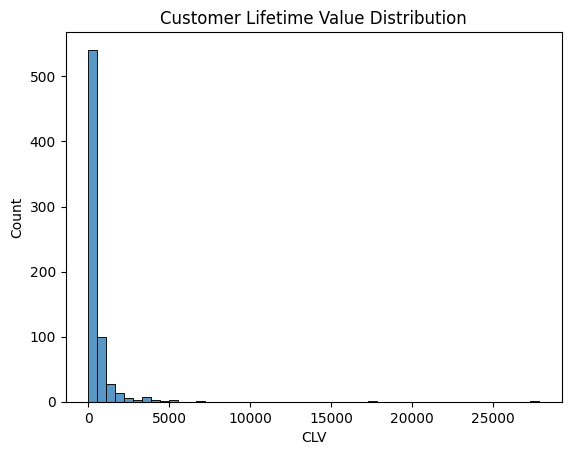

In [ ]:
sns.histplot(rfm['CLV'], bins=50)
plt.title("Customer Lifetime Value Distribution")
plt.show()

In [ ]:
rfm['CLV_segment'] = pd.qcut(
    rfm['CLV'],
    q=3,
    labels=['Low CLV','Medium CLV','High CLV']
)

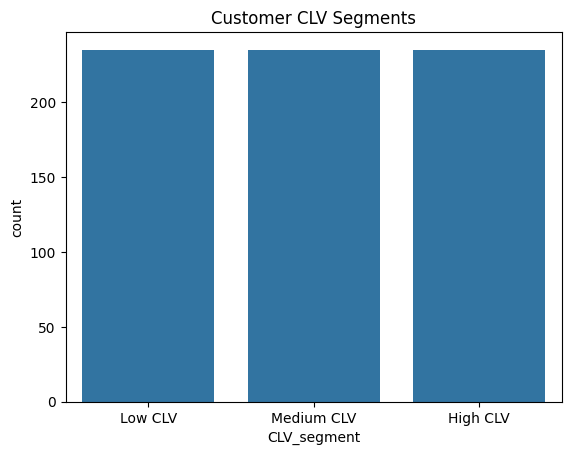

In [ ]:
sns.countplot(data=rfm, x='CLV_segment')
plt.title("Customer CLV Segments")
plt.show()

In [ ]:
segment_clv = rfm.groupby('Segment').agg({
    'CLV':'mean',
    'CustomerID':'count'
}).rename(columns={'CustomerID':'Customers'})

segment_clv

,CLV,Customers
Segment,,
At Risk,22589.695000,2
Champions,413.992950,400
Lost Customers,2656.933158,38
Loyal Customers,4523.625000,2
Potential Loyalists,345.255551,263


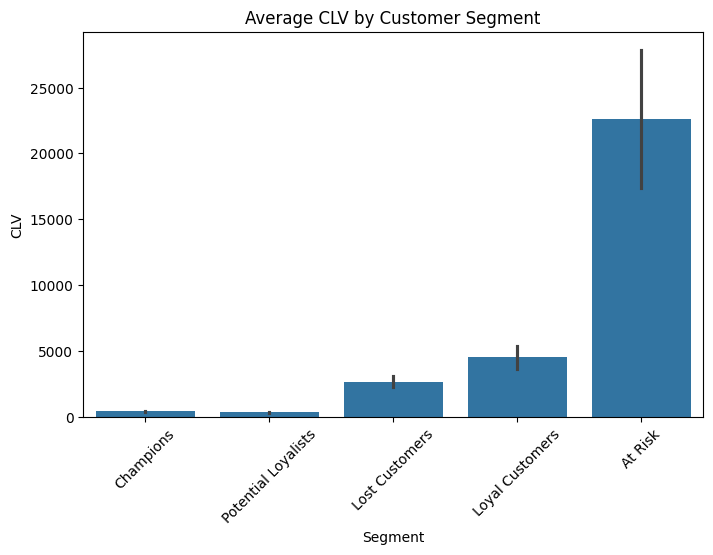

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=rfm,
    x='Segment',
    y='CLV'
)

plt.xticks(rotation=45)
plt.title("Average CLV by Customer Segment")
plt.show()

In [ ]:
rfm.to_csv("customer_clv_data.csv", index=False)